In [1]:
# Cell 1 — Installs & Imports

import subprocess
import sys

# Install helper — uses correct PyPI name if different from import name
def install_if_missing(package, install_name=None):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", install_name or package])

install_if_missing('sklearn', 'scikit-learn')
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('seaborn')

# --- Standard Library ---
import urllib.request
import tarfile
import os
import re
import pickle
from html import unescape

# --- Data & Viz ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# --- Global Config ---
RANDOM_SEED = 42  # Pass this to every estimator via random_state=RANDOM_SEED

print("✅ All imports successful | RANDOM_SEED =", RANDOM_SEED)

✅ All imports successful | RANDOM_SEED = 42


In [3]:
# Cell 2 — Mount Google Drive

# NOTE: This cell is Colab-specific. If running locally, skip it —
# SAVE_PATH will automatically fall back to /content/imdb_sentiment (or adjust below).

DRIVE_BASE = "/content/drive/MyDrive/imdb_sentiment"
LOCAL_BASE = "/content/imdb_sentiment"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = DRIVE_BASE
    print(f"✅ Google Drive mounted. Files will be saved to: {SAVE_PATH}")
except Exception as e:
    SAVE_PATH = LOCAL_BASE
    print(f"⚠️  Drive not available ({e}). Falling back to: {SAVE_PATH}")

os.makedirs(SAVE_PATH, exist_ok=True)
print(f"📁 Save path ready: {SAVE_PATH}")

⚠️  Drive not available (Error: credential propagation was unsuccessful). Falling back to: /content/imdb_sentiment
📁 Save path ready: /content/imdb_sentiment


In [4]:
# Cell 3 — Verify IMDb Dataset CSV

CSV_PATH = "/content/drive/MyDrive/DATASETS_For the data analysis/IMDB Dataset.csv"  # 🔧 Change this if your file has a different name or path

if os.path.exists(CSV_PATH):
    print(f"✅ '{CSV_PATH}' found.")
    sample = pd.read_csv(CSV_PATH, nrows=3)
    print("\nFirst 3 rows:")
    print(sample)
    print(f"\nColumns: {list(sample.columns)}")
else:
    print(f"❌ '{CSV_PATH}' not found!\n")
    print("📁 Upload options:")
    print("  Option 1: Left sidebar → Files icon → Upload button → select your CSV")
    print("  Option 2: Run the following in a new cell:")
    print("\n    from google.colab import files")
    print("    files.upload()")
    print("\nThen rerun this cell.")
    raise FileNotFoundError(f"'{CSV_PATH}' not found. Please upload it first.")

✅ '/content/drive/MyDrive/DATASETS_For the data analysis/IMDB Dataset.csv' found.

First 3 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Columns: ['review', 'sentiment']


In [5]:
# Cell 4 — Text Cleaning Function
# Cleans raw IMDb reviews by:
#   1. Unescaping HTML entities  (e.g. &amp; → &)
#   2. Stripping HTML tags       (e.g. <br />)
#   3. Lowercasing
#   4. Removing non-alphabetic characters
#   5. Collapsing extra whitespace

def clean_text(text):
    text = unescape(text)                          # &quot; → "
    text = re.sub(r'<[^>]+>', ' ', text)           # remove HTML tags
    text = text.lower()                            # lowercase
    text = re.sub(r'[^a-z\s]', '', text)           # keep only letters + spaces
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    return text

# Test — exercises all 5 steps
test = "This film was &amp; AMAZING!!!   <br /><br /> 10/10 would watch again."
print(f"Original : {test}")
print(f"Cleaned  : {clean_text(test)}")

Original : This film was &amp; AMAZING!!!   <br /><br /> 10/10 would watch again.
Cleaned  : this film was amazing would watch again


In [6]:
# Cell 5 — Load & Prepare Data
# Reads the CSV, applies clean_text(), and maps sentiment to integers.
# Expected columns: 'review' (str), 'sentiment' ("positive"/"negative")

print("📂 Loading CSV...")
df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")

print("\n🧹 Cleaning reviews (may take 1–2 minutes)...")
df['review'] = df['review'].apply(clean_text)

print("🔢 Encoding sentiment labels...")
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Catch any unexpected label values
if df['sentiment'].isna().any():
    print(f"⚠️  {df['sentiment'].isna().sum()} rows with unrecognized labels dropped.")
    df = df.dropna(subset=['sentiment'])

df['sentiment'] = df['sentiment'].astype(int)

print(f"\n✅ Final shape: {df.shape}")
print("\nClass distribution:")
print(df['sentiment'].value_counts().rename({1: 'Positive', 0: 'Negative'}))

print("\n📝 Sample cleaned review:")
print(df.iloc[0]['review'][:300] + "...")

📂 Loading CSV...
Raw shape: (50000, 2)

🧹 Cleaning reviews (may take 1–2 minutes)...
🔢 Encoding sentiment labels...

✅ Final shape: (50000, 2)

Class distribution:
sentiment
Positive    25000
Negative    25000
Name: count, dtype: int64

📝 Sample cleaned review:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a...


## Cell 6 — Train/Test Split Strategy

There are two ways to split the IMDb dataset:

**(a) Original IMDb split** — 25,000 train / 25,000 test, pre-assigned by Stanford. Useful if you want to benchmark against published research results.

**(b) Fresh stratified 80/20 split** — shuffle all 50,000 reviews and split randomly, keeping class proportions balanced. More flexible and standard practice for standalone projects.

**This notebook uses option (b).** With 50,000 reviews, an 80/20 split gives us 40,000 training samples and 10,000 test samples, stratified by sentiment.

In [8]:
# Cell 7 — Train/Test Split & TF-IDF Vectorization

# --- 80/20 Stratified Split ---
X = df['review'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"✅ Split complete:")
print(f"   Training samples : {len(X_train)}")
print(f"   Test samples     : {len(X_test)}")
print(f"   Train (neg/pos)  : {np.bincount(y_train)}")
print(f"   Test  (neg/pos)  : {np.bincount(y_test)}")

# --- TF-IDF Vectorization ---
# Fit ONLY on training data to prevent data leakage
print("\n⚙️  Fitting TF-IDF vectorizer on training set...")
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=10_000,  # top 10k features by TF-IDF score
    stop_words='english'  # remove common words (the, is, at...)
)

X_train_tfidf = vectorizer.fit_transform(X_train)  # fit + transform
X_test_tfidf  = vectorizer.transform(X_test)        # transform only — no leakage

print(f"✅ Vectorization complete:")
print(f"   Vocabulary size  : {len(vectorizer.get_feature_names_out())}")
print(f"   Train matrix     : {X_train_tfidf.shape}")
print(f"   Test matrix      : {X_test_tfidf.shape}")

✅ Split complete:
   Training samples : 40000
   Test samples     : 10000
   Train (neg/pos)  : [20000 20000]
   Test  (neg/pos)  : [5000 5000]

⚙️  Fitting TF-IDF vectorizer on training set...
✅ Vectorization complete:
   Vocabulary size  : 10000
   Train matrix     : (40000, 10000)
   Test matrix      : (10000, 10000)


In [9]:
%%time
# Cell 8 — Train Logistic Regression

print("⚙️  Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1  # use all available CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression training complete.")
print(f"   Solver    : {lr_model.solver}")
print(f"   Max iter  : {lr_model.max_iter}")
print(f"   Classes   : {lr_model.classes_}")

⚙️  Training Logistic Regression...
✅ Logistic Regression training complete.
   Solver    : lbfgs
   Max iter  : 1000
   Classes   : [0 1]
CPU times: user 42.5 ms, sys: 40 ms, total: 82.6 ms
Wall time: 3.19 s


Classification Report - Logistic Regression:

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



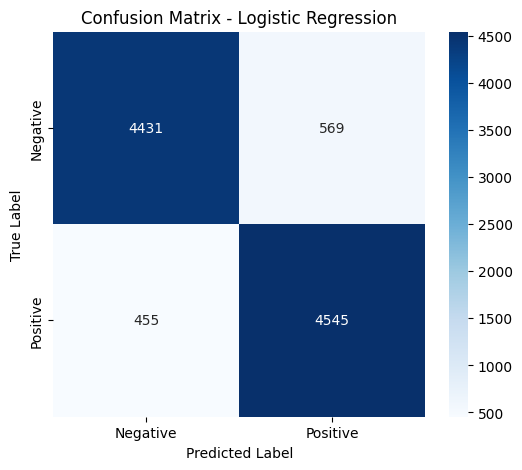

In [10]:
# Cell 9: Evaluate Logistic Regression
# Print classification report (precision, recall, f1, accuracy).
# Plot a labeled confusion matrix heatmap with seaborn.

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Classification report
print("Classification Report - Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [11]:
# Cell 10: Custom Review Predictions
# Define 3 placeholder reviews: positive, negative, ambiguous.
# For each, print the review, predicted label, and confidence probability.

# Define custom reviews
custom_reviews = [
    ("This movie was absolutely fantastic! The acting, the plot, everything was perfect. I loved every minute of it.", "positive"),
    ("Terrible waste of time. Boring script, horrible acting, and the sound was awful. I want my money back.", "negative"),
    ("The movie was okay. Some parts were interesting but it was too long and the ending was confusing.", "ambiguous")
]

print("Custom Review Predictions:\n" + "="*60)

for review_text, expected in custom_reviews:
    # Clean and vectorize
    cleaned = clean_text(review_text)
    vec = vectorizer.transform([cleaned])

    # Predict and get probability
    pred = lr_model.predict(vec)[0]
    prob = lr_model.predict_proba(vec)[0]
    confidence = prob[pred] * 100

    sentiment = "Positive" if pred == 1 else "Negative"

    print(f"\nReview: {review_text[:100]}...")
    print(f"Expected sentiment: {expected}")
    print(f"Predicted: {sentiment} ({confidence:.1f}% confident)")
    print("-"*60)

Custom Review Predictions:

Review: This movie was absolutely fantastic! The acting, the plot, everything was perfect. I loved every min...
Expected sentiment: positive
Predicted: Positive (94.3% confident)
------------------------------------------------------------

Review: Terrible waste of time. Boring script, horrible acting, and the sound was awful. I want my money bac...
Expected sentiment: negative
Predicted: Negative (100.0% confident)
------------------------------------------------------------

Review: The movie was okay. Some parts were interesting but it was too long and the ending was confusing....
Expected sentiment: ambiguous
Predicted: Negative (86.1% confident)
------------------------------------------------------------


In [12]:
%%time
# Cell 11: Bonus - Train and Evaluate Naive Bayes and LinearSVC
# Train MultinomialNB and LinearSVC on the same TF-IDF features.
# Create a summary comparison table with all three models.

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Train Naive Bayes
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# Train LinearSVC
print("Training Linear SVC...")
svc_model = LinearSVC(random_state=RANDOM_SEED, max_iter=3000, dual='auto')
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)

# Evaluate all three
results = []

for name, y_pred in [("Logistic Regression", y_pred_lr),
                      ("Naive Bayes", y_pred_nb),
                      ("Linear SVC", y_pred_svc)]:
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1 Score": f"{f1:.4f}"
    })

# Summary table
summary_df = pd.DataFrame(results)
print("\n" + "="*70)
print("Model Comparison Summary")
print("="*70)
print(summary_df.to_string(index=False))

Training Multinomial Naive Bayes...
Training Linear SVC...

Model Comparison Summary
              Model Accuracy Precision Recall F1 Score
Logistic Regression   0.8976    0.8887 0.9090   0.8988
        Naive Bayes   0.8640    0.8530 0.8796   0.8661
         Linear SVC   0.8888    0.8845 0.8944   0.8894
CPU times: user 3.19 s, sys: 1.27 ms, total: 3.19 s
Wall time: 2.93 s


In [13]:
# Cell 12: Save Models with Pickle
# Save the TF-IDF vectorizer and Logistic Regression model.
# Save to Google Drive path (fallback to /content/ if Drive not mounted).
# Print the saved file paths.

import pickle

# Ensure save directory exists
os.makedirs(SAVE_PATH, exist_ok=True)

# Save vectorizer
vectorizer_path = os.path.join(SAVE_PATH, "tfidf_vectorizer.pkl")
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"Vectorizer saved to: {vectorizer_path}")

# Save Logistic Regression model
model_path = os.path.join(SAVE_PATH, "logistic_regression_model.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"Logistic Regression model saved to: {model_path}")

# Optional: save the comparison summary as CSV
csv_path = os.path.join(SAVE_PATH, "model_comparison.csv")
summary_df.to_csv(csv_path, index=False)
print(f"Model comparison saved to: {csv_path}")

# Also save the cleaned DataFrame (optional, for reuse)
df_path = os.path.join(SAVE_PATH, "cleaned_imdb_reviews.csv")
df.to_csv(df_path, index=False)
print(f"Cleaned dataset saved to: {df_path}")

print("\n✅ All models and artifacts saved successfully!")

Vectorizer saved to: /content/imdb_sentiment/tfidf_vectorizer.pkl
Logistic Regression model saved to: /content/imdb_sentiment/logistic_regression_model.pkl
Model comparison saved to: /content/imdb_sentiment/model_comparison.csv
Cleaned dataset saved to: /content/imdb_sentiment/cleaned_imdb_reviews.csv

✅ All models and artifacts saved successfully!
